## BUSINESS UNDERSTANDING AND PROBLEM FRAMING

PowerCo is experiencing increasing customer churn as customers switch to competitors offering better deals and pricing options. The company suspects that price sensitivity may be a major factor influencing this behavior. The goal is to generate data-driven insights that will help PowerCo improve customer retention and reduce future churn.


HYPOTHESIS
+ H₀: There is no relationship between price sensitivity and customer churn.
+ H₁: There is a significant relationship between price sensitivity and customer churn.

# Import packages

In [1]:
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For plotting and data visualization
import pandas as pd # For data manipulation and analysis

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---

## Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python. For this notebook and all further notebooks, it will be assumed that the CSV files will the placed in the same file location as the notebook. If they are not, please adjust the directory within the `read_csv` method accordingly.

In [2]:
# Load the datasets

client_df = pd.read_csv('datasets/client_data.csv')
price_df = pd.read_csv('datasets/price_data.csv')

## EXPLORATORY DATA ANALYSIS

In [3]:
# Display the first few rows of the client dataset
client_df.head(10)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0
5,1aa498825382410b098937d65c4ec26d,usilxuppasemubllopkaafesmlibmsdf,8302,0,1998,2011-12-09,2016-12-09,2015-11-01,2015-12-10,796.94,...,f,181.21,33.12,33.12,1,118.89,4,lxidpiddsbxsbosboudacockeimpuepw,13.200,1
6,7ab4bf4878d8f7661dfc20e9b8e18011,foosdfpfkusacimwkcsosbicdxkicaua,45097,0,0,2011-12-02,2016-12-02,2011-12-02,2015-12-03,8069.28,...,f,0.00,4.04,4.04,1,346.63,4,lxidpiddsbxsbosboudacockeimpuepw,15.000,1
7,01495c955be7ec5e7f3203406785aae0,foosdfpfkusacimwkcsosbicdxkicaua,29552,0,1260,2010-04-21,2016-04-21,2010-04-21,2015-04-22,864.73,...,f,70.63,53.92,53.92,1,100.09,6,lxidpiddsbxsbosboudacockeimpuepw,26.400,0
8,f53a254b1115634330c12c7fdbf7958a,usilxuppasemubllopkaafesmlibmsdf,2962,0,0,2011-09-23,2016-09-23,2011-09-23,2015-09-25,444.38,...,f,0.00,12.82,12.82,1,42.59,4,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
9,10c1b2f97a2d2a6f10299dc213d1a370,lmkebamcaaclubfxadlmueccxoimlema,26064,0,2188,2010-05-04,2016-05-04,2015-04-29,2015-05-05,2738.10,...,f,219.59,33.42,33.42,1,329.60,6,lxidpiddsbxsbosboudacockeimpuepw,31.500,0


In [4]:
client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [5]:
# Display the first few rows of the price dataset
price_df.head(10)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0
5,038af19179925da21a25619c5a24b745,2015-06-01,0.149626,0.0,0.0,44.266930,0.0,0.0
6,038af19179925da21a25619c5a24b745,2015-07-01,0.150321,0.0,0.0,44.444710,0.0,0.0
7,038af19179925da21a25619c5a24b745,2015-08-01,0.145859,0.0,0.0,44.444710,0.0,0.0
8,038af19179925da21a25619c5a24b745,2015-09-01,0.145859,0.0,0.0,44.444710,0.0,0.0
9,038af19179925da21a25619c5a24b745,2015-10-01,0.145859,0.0,0.0,44.444710,0.0,0.0


In [6]:
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  str    
 1   price_date          193002 non-null  str    
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), str(2)
memory usage: 11.8 MB


+ Both datasets have "id" which is client company identifier.
+ We can merge datasets on "id"

In [7]:
client_df['id'].unique()

<StringArray>
['24011ae4ebbe3035111d65fa7c15bc57', 'd29c2c54acc38ff3c0614d0a653813dd',
 '764c75f661154dac3a6c254cd082ea7d', 'bba03439a292a1e166f80264c16191cb',
 '149d57cf92fc41cf94415803a877cb4b', '1aa498825382410b098937d65c4ec26d',
 '7ab4bf4878d8f7661dfc20e9b8e18011', '01495c955be7ec5e7f3203406785aae0',
 'f53a254b1115634330c12c7fdbf7958a', '10c1b2f97a2d2a6f10299dc213d1a370',
 ...
 'c3f4f737d598a1b47a94440bb18c3c06', 'ae818f3cc00ef5845416699aacc4bd7e',
 '1582ef35fbfa265e60bb3399bdebac87', '46362cb1ad2fcdad347a6fa1bc1e5d4b',
 'c49217f16a06263e5381eaba94a67a8b', '18463073fb097fc0ac5d3e040f356987',
 'd0a6f71671571ed83b2645d23af6de00', '10e6828ddd62cbcf687cb74928c4c2d2',
 '1cf20fd6206d7678d5bcafd28c53b4db', '563dde550fd624d7352f3de77c0cdfcd']
Length: 14606, dtype: str

In [8]:
price_df["id"].unique()

<StringArray>
['038af19179925da21a25619c5a24b745', '31f2ce549924679a3cbb2d128ae9ea43',
 '36b6352b4656216bfdb96f01e9a94b4e', '48f3e6e86f7a8656b2c6b6ce2763055e',
 'cce88c7d721430d8bd31f71ae686c91e', '7363a2ebfbb3148c8ef6d25323e4093a',
 'ef716222bbd97a8bdfcbb831e3575560', '92857f88c0e1c54124846d128eb73d36',
 '1bbfa3a2744676a8aae9a9c3d0e7aeb1', 'c2ee885669b500427c11c75ca8de0db0',
 ...
 'd625f9e90d4af9986197444361e99235', 'b4033c524068af1ef66da2703d4a924a',
 '4ce4a572d6a97185f50d70e5cdc4129a', 'feefbb8a6b2491c45d6fbd5ab39dcfa3',
 'c7caf1d4ff2ea8e133509dc4fc61524e', 'cd622263c26436d1237e94ff05cdd506',
 'ed3434c3c1e2056d1a313e2671815e4d', 'd00da2c0c568614b9937791f681cd7d7',
 '045f94f0b7f538a8d8fae11080abb5da', '16f51cdc2baa19af0b940ee1b3dd17d5']
Length: 16096, dtype: str

price_df contains multiple entries for each customer. To merge with client_df the price must ve condensed so that there is one representative row per id 

In [9]:
# aggregate price data
price_agg = price_df.groupby("id").mean(numeric_only=True).reset_index()
price_agg

,id,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.000000,44.385450,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.000000,45.319710,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032,40.647427,24.388455,16.258971
4,00114d74e963e47177db89bc70108537,0.147926,0.000000,0.000000,44.266930,0.000000,0.000000
...,...,...,...,...,...,...,...
16091,ffef185810e44254c3a4c6395e6b4d8a,0.138863,0.115125,0.080780,40.896427,24.637456,16.507972
16092,fffac626da707b1b5ab11e8431a4d0a2,0.147137,0.000000,0.000000,44.311375,0.000000,0.000000
16093,fffc0cacd305dd51f316424bbb08d1bd,0.153879,0.129497,0.094842,41.160171,24.895768,16.763569
16094,fffe4f5646aa39c7f97f95ae2679ce64,0.123858,0.103499,0.073735,40.606699,24.364017,16.242678


In [10]:
# Merge datasets client_df and price_agg

data = pd.merge(client_df,price_agg, on="id", how="left",)

# preview data
data

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,num_years_antig,origin_up,pow_max,churn,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,0.124787,0.100749,0.066530,40.942265,22.352010,14.901340
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,0.149609,0.007124,0.000000,44.311375,0.000000,0.000000
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,0.170512,0.088421,0.000000,44.385450,0.000000,0.000000
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,0.151210,0.000000,0.000000,44.400265,0.000000,0.000000
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,0.124174,0.103638,0.072865,40.688156,24.412893,16.275263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.01,...,4,lxidpiddsbxsbosboudacockeimpuepw,15.000,0,0.144124,0.000000,0.000000,44.370635,0.000000,0.000000
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.69,...,3,lxidpiddsbxsbosboudacockeimpuepw,6.000,1,0.106799,0.095406,0.070817,59.015674,36.393379,8.345418
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.39,...,4,lxidpiddsbxsbosboudacockeimpuepw,15.935,1,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.34,...,3,lxidpiddsbxsbosboudacockeimpuepw,11.000,0,0.149609,0.007124,0.000000,44.311375,0.000000,0.000000


In [11]:
# check for null values
data.isnull().sum()


id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
price_off_peak_var                0
price_peak_var              

In [12]:
data['channel_sales'].value_counts()

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

In [13]:
data.shape

(14606, 32)

In [14]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
cons_12m,14606.0,159220.286252,573465.264198,0.0,5674.750000,14115.500000,40763.750000,6.207104e+06
cons_gas_12m,14606.0,28092.375325,162973.059057,0.0,0.000000,0.000000,0.000000,4.154590e+06
cons_last_month,14606.0,16090.269752,64364.196422,0.0,0.000000,792.500000,3383.000000,7.712030e+05
forecast_cons_12m,14606.0,1868.614880,2387.571531,0.0,494.995000,1112.875000,2401.790000,8.290283e+04
forecast_cons_year,14606.0,1399.762906,3247.786255,0.0,0.000000,314.000000,1745.750000,1.753750e+05
forecast_discount_energy,14606.0,0.966726,5.108289,0.0,0.000000,0.000000,0.000000,3.000000e+01
forecast_meter_rent_12m,14606.0,63.086871,66.165783,0.0,16.180000,18.795000,131.030000,5.993100e+02
forecast_price_energy_off_peak,14606.0,0.137283,0.024623,0.0,0.116340,0.143166,0.146348,2.739630e-01
forecast_price_energy_peak,14606.0,0.050491,0.049037,0.0,0.000000,0.084138,0.098837,1.959750e-01
forecast_price_pow_off_peak,14606.0,43.130056,4.485988,0.0,40.606701,44.311378,44.311378,5.926638e+01


In [15]:
churn_counts = data['churn'].value_counts()
churn_counts

churn
0    13187
1     1419
Name: count, dtype: int64

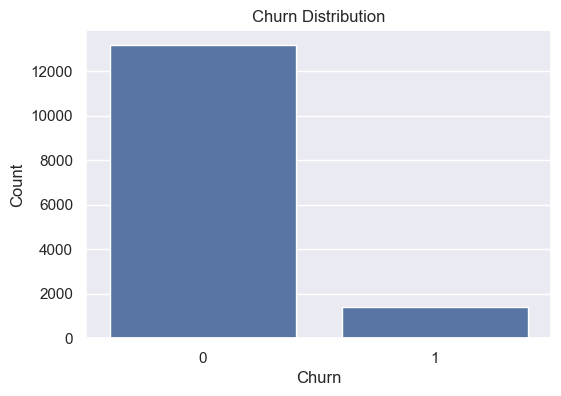

In [16]:
# check the churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=data)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()


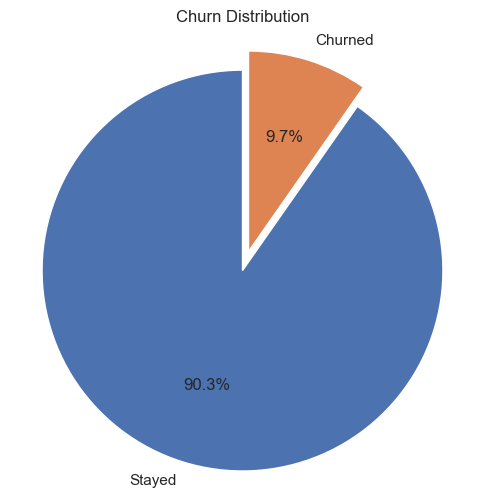

In [17]:
plt.figure(figsize=(6,6))
colors = ['blue','red']
plt.pie (
    churn_counts,
    labels= ['Stayed', 'Churned'],
    autopct='%1.1f%%',
    #colors=colors,
    startangle=90,
    explode=(0, 0.1),
    
)
plt.axis('equal') 
plt.title('Churn Distribution')
plt.show()


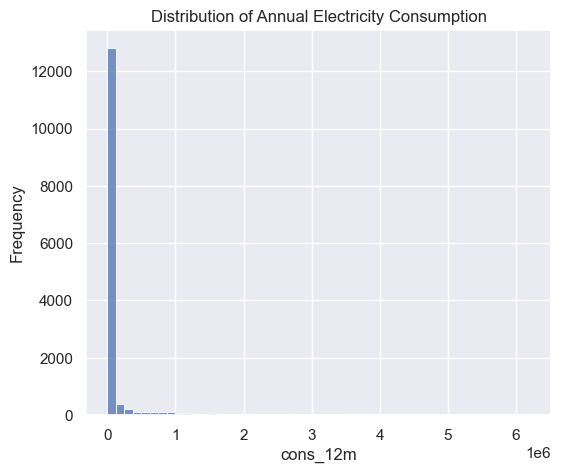

In [18]:
# Distribution of Annual Electricity Consumption
plt.figure(figsize=(6,5))

sns.histplot(data['cons_12m'], bins=50)

plt.title('Distribution of Annual Electricity Consumption')
plt.xlabel('cons_12m')
plt.ylabel('Frequency')

plt.show()

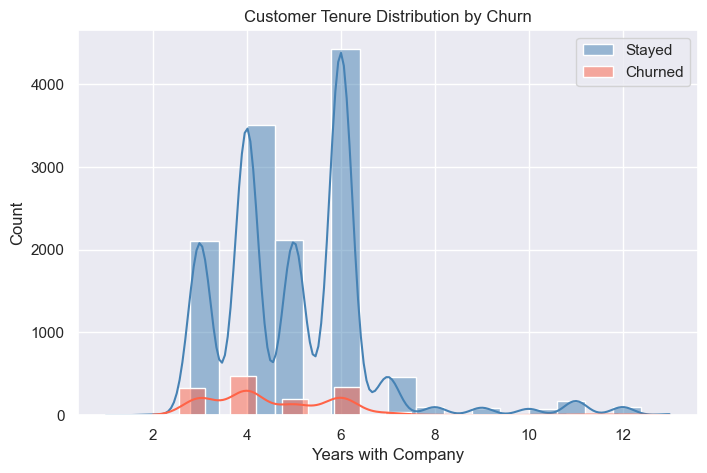

In [19]:
plt.figure(figsize=(8,5))

for churn_val, label, color in zip([0, 1], ['Stayed', 'Churned'], ['steelblue', 'tomato']):
    subset = data[data['churn'] == churn_val]['num_years_antig']
    sns.histplot(subset, kde=True, label=label, color=color, alpha=0.5, bins=20)

plt.title('Customer Tenure Distribution by Churn')
plt.xlabel('Years with Company')
plt.ylabel('Count')
plt.legend()
plt.show()

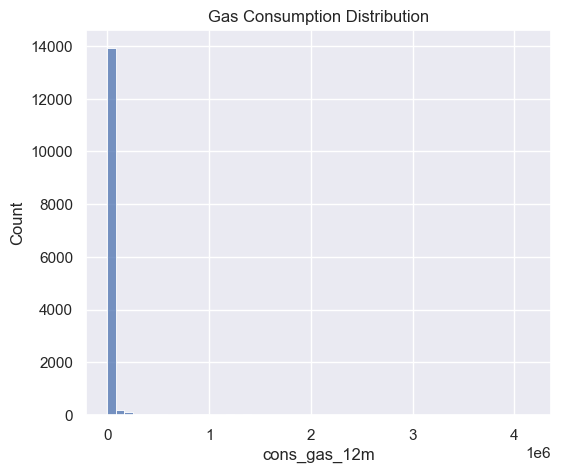

In [20]:
# Distribution of Gas Consumption
plt.figure(figsize=(6,5))

sns.histplot(data['cons_gas_12m'], bins=50)

plt.title('Gas Consumption Distribution')
plt.xlabel('cons_gas_12m')

plt.show()

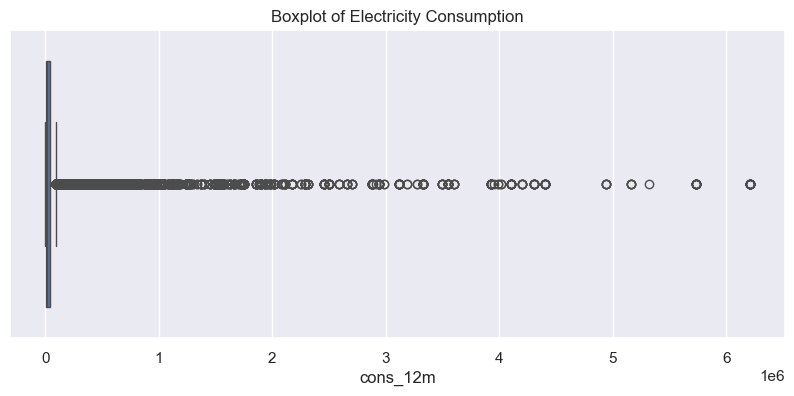

In [21]:
# Boxplot of Electricity Consumption
plt.figure(figsize=(10,4))

sns.boxplot(x=data['cons_12m'])

plt.title('Boxplot of Electricity Consumption')

plt.show()

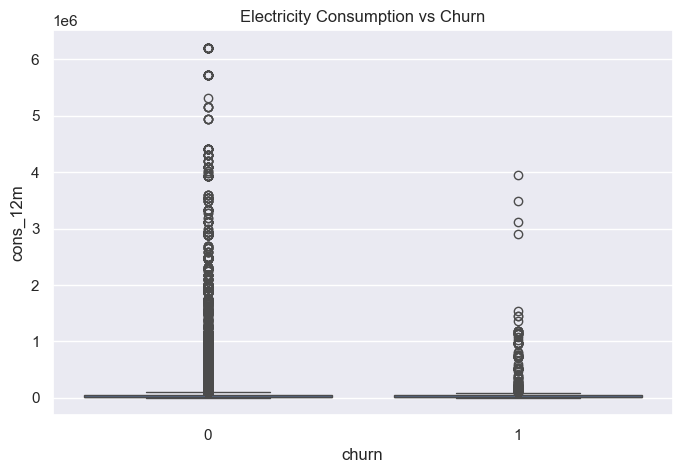

In [22]:
# 
plt.figure(figsize=(8,5))

sns.boxplot(x='churn', y='cons_12m', data=data)

plt.title('Electricity Consumption vs Churn')

plt.show()

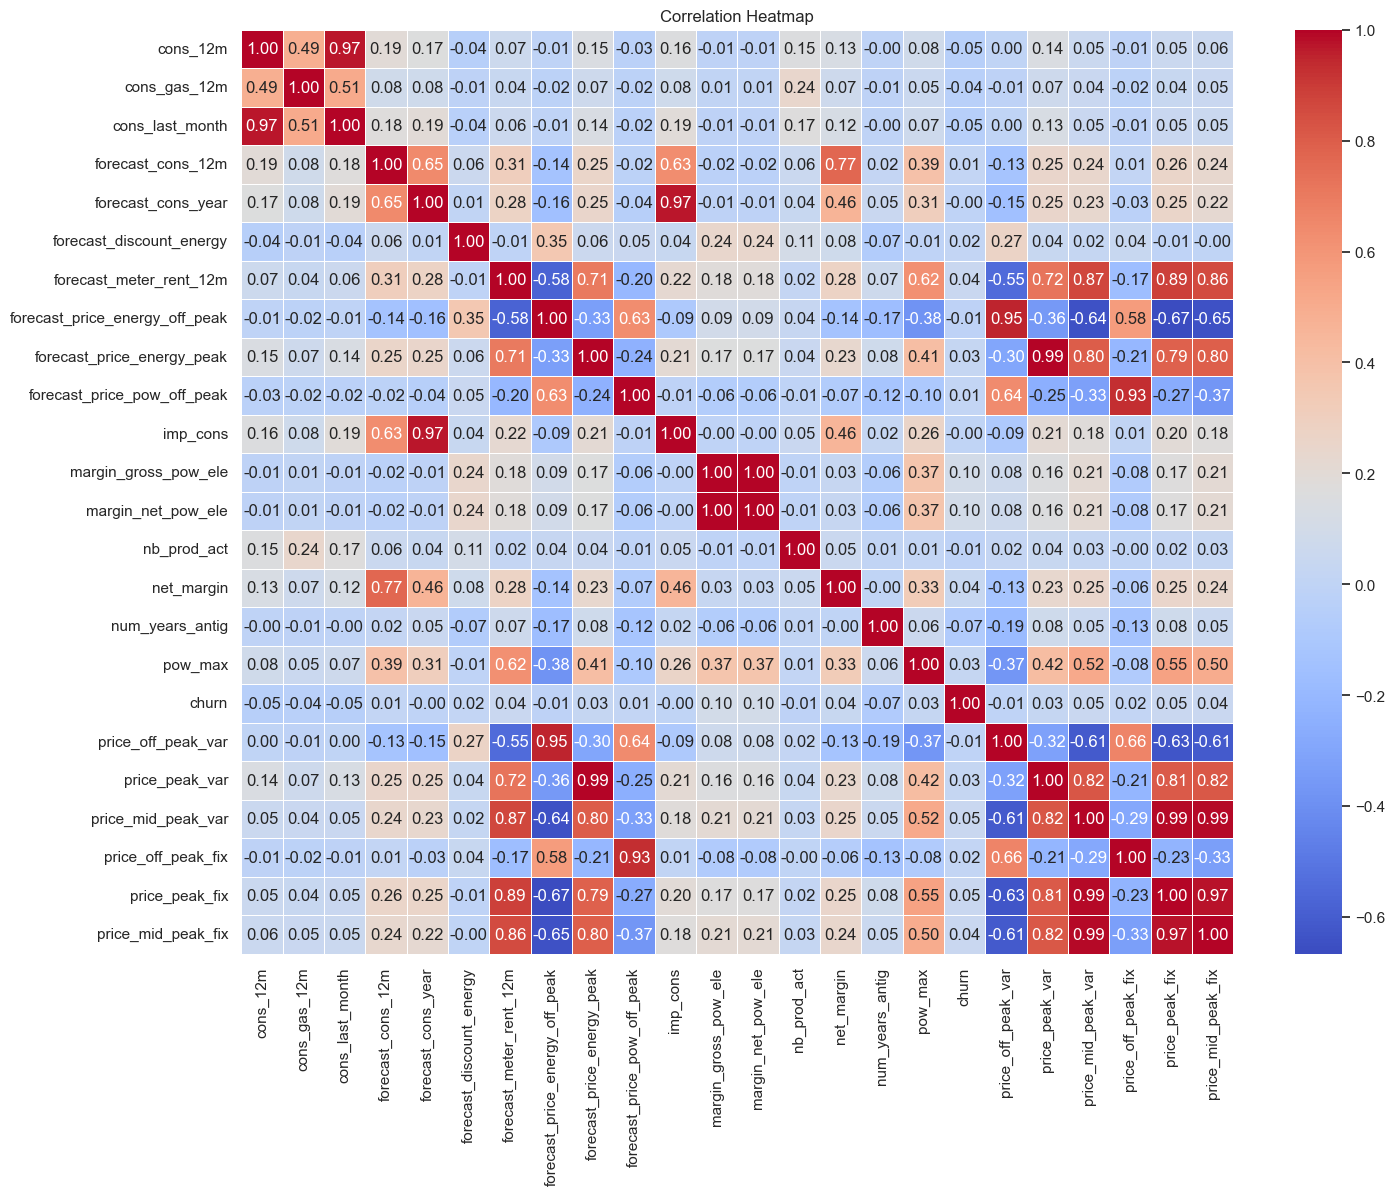

In [23]:
# correlation
correlation = data.corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


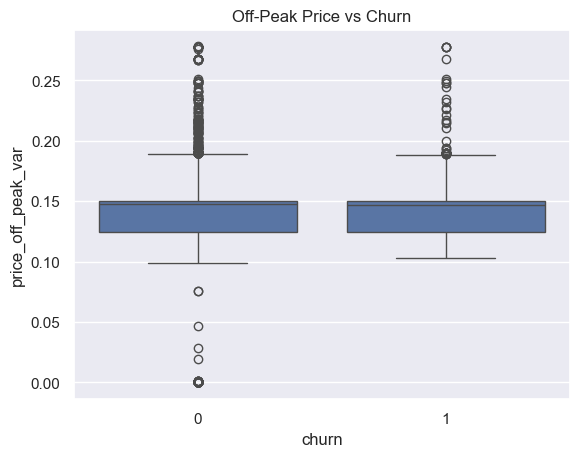

In [24]:
sns.boxplot(data=data, x='churn', y='price_off_peak_var')
plt.title("Off-Peak Price vs Churn")
plt.show()


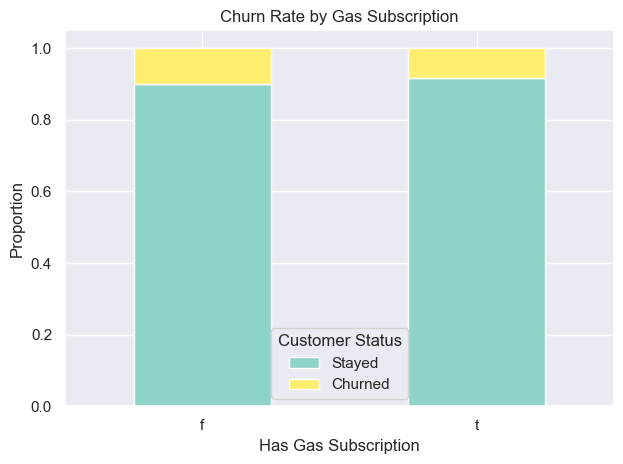

In [25]:
# Create crosstab with normalized values
churn_by_gas = pd.crosstab(data['has_gas'], data['churn'], normalize='index')

# Rename columns for better labels
churn_by_gas.columns = ['Stayed', 'Churned']

# Plot
churn_by_gas.plot(kind='bar', stacked=True, colormap='Set3')
plt.title("Churn Rate by Gas Subscription")
plt.ylabel("Proportion")
plt.xlabel("Has Gas Subscription")
plt.legend(title="Customer Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [26]:
data['has_gas'].value_counts()

has_gas
f    11955
t     2651
Name: count, dtype: int64

In [27]:
price_cols = [
    'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix'
]


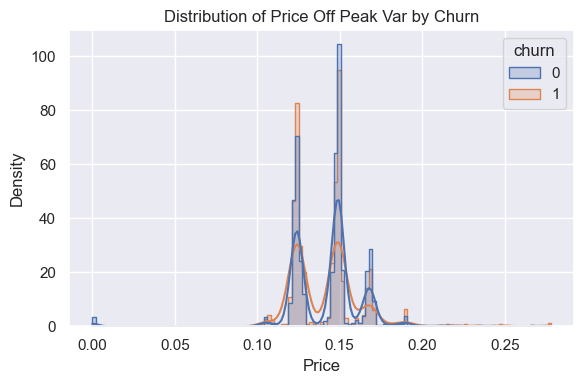

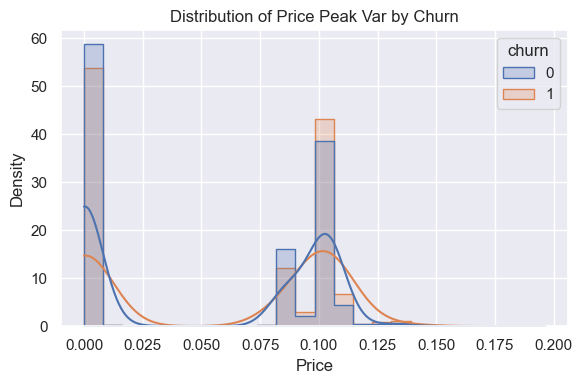

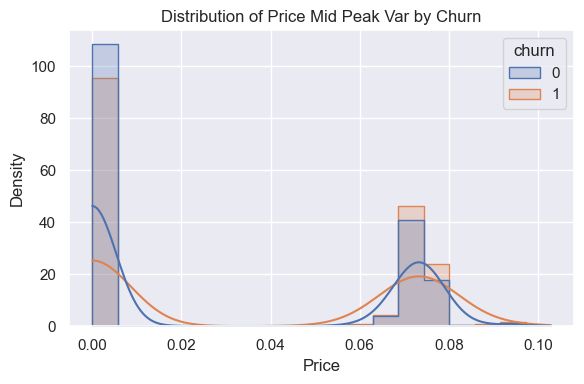

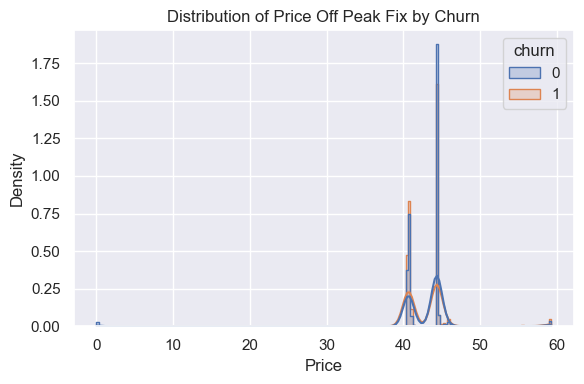

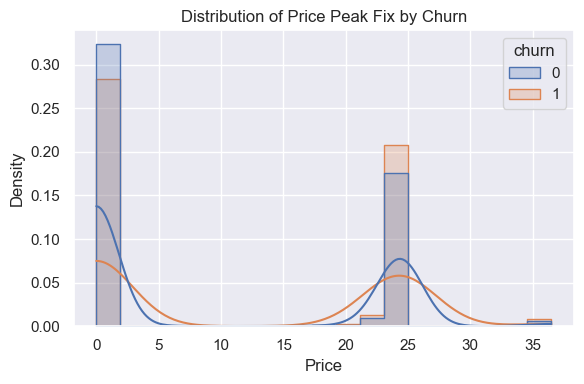

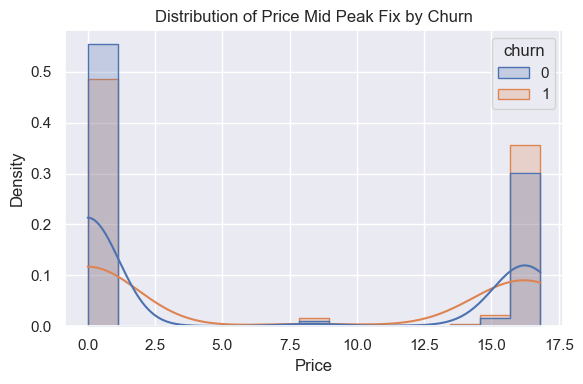

In [28]:
for col in price_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=data, x=col, hue='churn', kde=True, element='step', stat='density', common_norm=False)
    plt.title(f"Distribution of {col.replace('_', ' ').title()} by Churn")
    plt.xlabel("Price")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()


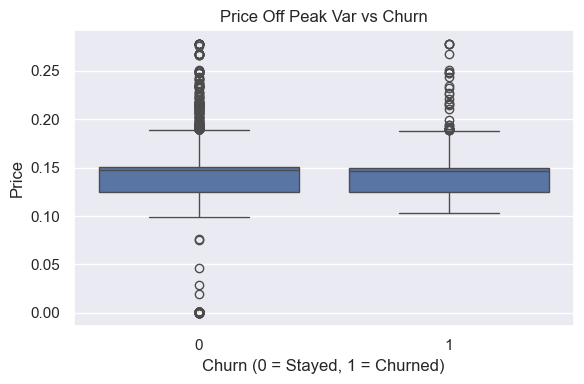

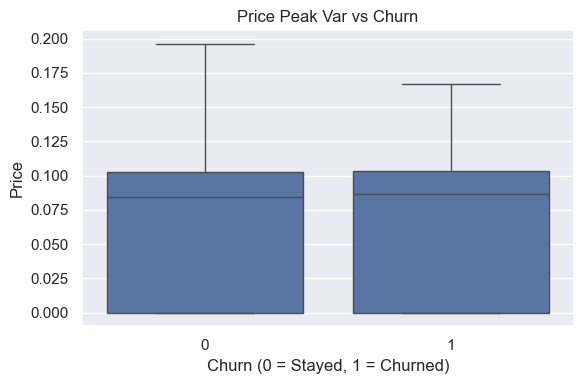

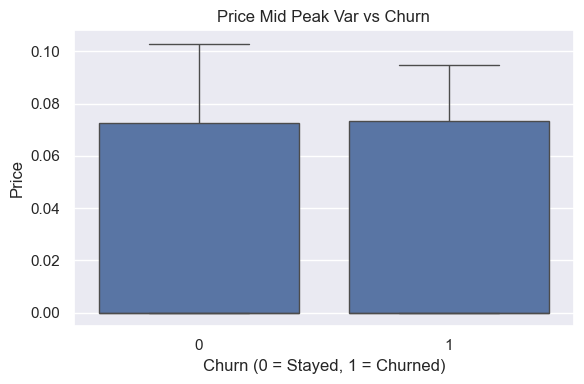

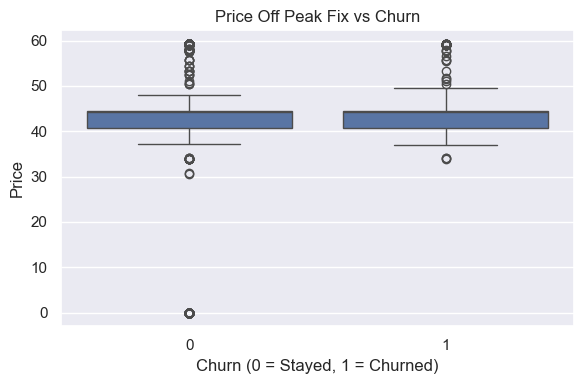

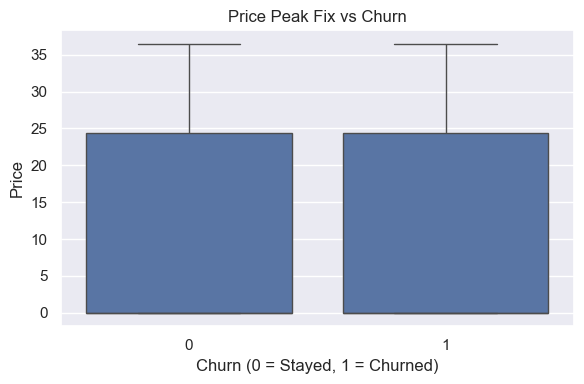

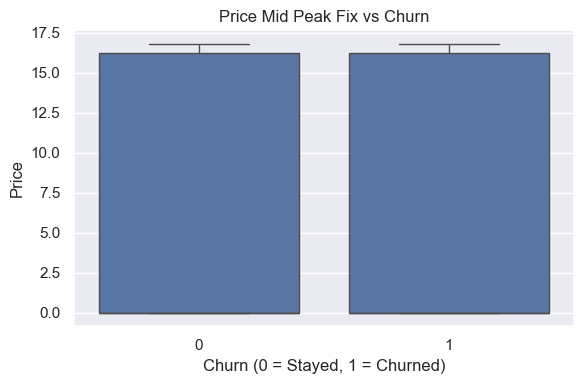

In [29]:
for col in price_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data, x='churn', y=col)
    plt.title(f"{col.replace('_', ' ').title()} vs Churn")
    plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
    plt.ylabel("Price")
    plt.tight_layout()
    plt.show()


In [30]:
data.to_csv('datasets/data.csv', index=False)

# INSIGHTS
+ Off-peak price alone may not be a strong driver of churn.
+ The distribution of off-peak prices is nearly the same for both groups.
+ Customers are paying similar off-peak prices regardless of churn status.
+ The data is imbalance.
+ The churned distribution peaks around year 3 to 4. 
+ This means customers are most likely to leave between their 3rd and 4th year.

# FEATURE ENGINEERING

In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [32]:
# define date columns
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']

# convert date column to datetime
for col in date_cols:
    data[col] = pd.to_datetime(data[col])

In [33]:
# create new feature 'contract_duration' as the difference between 'date_end' and 'date_activ'
data['contract_duration'] = (data['date_end'] - data['date_activ']).dt.days

In [34]:
data

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,origin_up,pow_max,churn,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,contract_duration
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,0.124787,0.100749,0.066530,40.942265,22.352010,14.901340,1096
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,0.149609,0.007124,0.000000,44.311375,0.000000,0.000000,2566
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,0.170512,0.088421,0.000000,44.385450,0.000000,0.000000,2192
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,0.151210,0.000000,0.000000,44.400265,0.000000,0.000000,2192
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,0.124174,0.103638,0.072865,40.688156,24.412893,16.275263,2245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.01,...,lxidpiddsbxsbosboudacockeimpuepw,15.000,0,0.144124,0.000000,0.000000,44.370635,0.000000,0.000000,1445
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.69,...,lxidpiddsbxsbosboudacockeimpuepw,6.000,1,0.106799,0.095406,0.070817,59.015674,36.393379,8.345418,1461
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.39,...,lxidpiddsbxsbosboudacockeimpuepw,15.935,1,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694,1460
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.34,...,lxidpiddsbxsbosboudacockeimpuepw,11.000,0,0.149609,0.007124,0.000000,44.311375,0.000000,0.000000,1461


In [38]:
data['channel_sales'].value_counts()

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
unknown                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

In [37]:
# replace 'MISSING' with 'unknown'
data['channel_sales'] = data['channel_sales'].replace('MISSING', 'unknown')

# View the updated data
data


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,origin_up,pow_max,churn,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,contract_duration
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,0.124787,0.100749,0.066530,40.942265,22.352010,14.901340,1096
1,d29c2c54acc38ff3c0614d0a653813dd,unknown,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,0.149609,0.007124,0.000000,44.311375,0.000000,0.000000,2566
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,0.170512,0.088421,0.000000,44.385450,0.000000,0.000000,2192
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,0.151210,0.000000,0.000000,44.400265,0.000000,0.000000,2192
4,149d57cf92fc41cf94415803a877cb4b,unknown,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,0.124174,0.103638,0.072865,40.688156,24.412893,16.275263,2245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.01,...,lxidpiddsbxsbosboudacockeimpuepw,15.000,0,0.144124,0.000000,0.000000,44.370635,0.000000,0.000000,1445
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.69,...,lxidpiddsbxsbosboudacockeimpuepw,6.000,1,0.106799,0.095406,0.070817,59.015674,36.393379,8.345418,1461
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.39,...,lxidpiddsbxsbosboudacockeimpuepw,15.935,1,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694,1460
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.34,...,lxidpiddsbxsbosboudacockeimpuepw,11.000,0,0.149609,0.007124,0.000000,44.311375,0.000000,0.000000,1461


In [40]:
# Total price paid by each customer

data['total_price'] = (
    data['price_off_peak_var'] + data['price_peak_var'] + data['price_mid_peak_var'] +
    data['price_off_peak_fix'] + data['price_peak_fix'] + data['price_mid_peak_fix']
)

# total consumption
data['total_consumption'] = (data['cons_12m'] + data['cons_gas_12m'] + data['cons_last_month'])

# preview data
data.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,churn,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,contract_duration,total_price,total_consumption
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,1,0.124787,0.100749,0.066530,40.942265,22.352010,14.901340,1096,78.487683,54946
1,d29c2c54acc38ff3c0614d0a653813dd,unknown,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0,0.149609,0.007124,0.000000,44.311375,0.000000,0.000000,2566,44.468108,4660
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0,0.170512,0.088421,0.000000,44.385450,0.000000,0.000000,2192,44.644383,544
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0,0.151210,0.000000,0.000000,44.400265,0.000000,0.000000,2192,44.551475,1584
4,149d57cf92fc41cf94415803a877cb4b,unknown,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0,0.124174,0.103638,0.072865,40.688156,24.412893,16.275263,2245,81.676990,4951
